In [35]:
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

In [36]:
train = pd.read_csv("basic_train_set.csv")
test = pd.read_csv("basic_test_set.csv")


In [37]:
y_train = train['ClosePrice']
y_test = test['ClosePrice']

feature_cols = ['Latitude', 'Longitude', 'LivingArea', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet', 'Levels_MultiSplit', 'NumLevels']

X_train = train[feature_cols]
X_test = test[feature_cols]

# Models to Test
We will be trying out both RandomForest and DecisionTree models. Considering the amount of variables here, we can rule out Decision Trees as a viable set, but we will entertain it for completeness.

In [38]:
feature_cols = ['Latitude', 'Longitude', 'LivingArea', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet', 'Levels_MultiSplit', 'NumLevels']
X_train_full = train[feature_cols]
X_test_full = test[feature_cols]



model_full = LinearRegression()
model_full.fit(X_train_full, y_train)
y_pred_full = model_full.predict(X_test_full)


r2_full = r2_score(y_test, y_pred_full)


print(f"R-squared Score: {r2_full:.2f}")

R-squared Score: 0.39


In [39]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error


# 3. Train Decision Tree
# max_depth keeps the tree from growing indefinitely and overfitting
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
print(f"Decision Tree R2: {r2_score(y_test, dt_preds):.3f}, MAE: {mean_absolute_error(y_test, dt_preds):,.0f}, MAPE: {mean_absolute_percentage_error(y_test, dt_preds):.2%}")

# 4. Train Random Forest
# n_jobs=-1 uses all available cores; max_depth bounds tree size so training doesn't blow up
# n_estimators is the number of individual trees in the forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, verbose=1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print(f"Random Forest R2: {r2_score(y_test, rf_preds):.3f}, MAE: {mean_absolute_error(y_test, rf_preds):,.0f}, MAPE: {mean_absolute_percentage_error(y_test, rf_preds):.2%}")

Decision Tree R2: 0.784, MAE: 176,407, MAPE: 16.42%


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    4.1s


Random Forest R2: 0.892, MAE: 121,133, MAPE: 11.06%


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   18.9s finished
[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.1s finished


In [40]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

# 5. Random Forest on log-transformed target
# ClosePrice is right-skewed, so training on log1p(price) and inverting with expm1
# tends to fit better and reduce error on high-end homes
y_train_log = np.log1p(y_train)

rf_log_model = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, verbose=1)
rf_log_model.fit(X_train, y_train_log)

rf_log_preds = np.expm1(rf_log_model.predict(X_test))
print(f"Random Forest (log target) R2: {r2_score(y_test, rf_log_preds):.3f}, MAE: {mean_absolute_error(y_test, rf_log_preds):,.0f}, MAPE: {mean_absolute_percentage_error(y_test, rf_log_preds):.2%}")

model_full_log = LinearRegression()
model_full_log.fit(X_train_full, y_train_log)
y_pred_full_log = np.expm1(model_full_log.predict(X_test_full))

r2_full_log = r2_score(y_test, y_pred_full_log)

print(f"LinReg (log target) R-squared Score: {r2_full_log:.2f}")

dt_log_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)
dt_log_model.fit(X_train, y_train_log)
dt_log_preds = np.expm1(dt_log_model.predict(X_test))
print(f"Decision Tree (log target) R2: {r2_score(y_test, dt_log_preds):.3f}, MAE: {mean_absolute_error(y_test, dt_log_preds):,.0f}, MAPE: {mean_absolute_percentage_error(y_test, dt_log_preds):.2%}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   18.3s finished
[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.1s finished


Random Forest (log target) R2: 0.877, MAE: 126,892, MAPE: 11.18%
LinReg (log target) R-squared Score: 0.33
Decision Tree (log target) R2: 0.757, MAE: 182,279, MAPE: 16.12%


# Notes 
-For baseline tests, it seems like randomforest performs significantly better than decision tree on all metrics except MBAPE
-Log seems to slightly decrease the MBAPE but slightly increases the MAE. The changes are very negligible.

# Feature Importance & Diagnostics

Latitude                 0.336752
Longitude                0.309057
LivingArea               0.236231
YearBuilt                0.033400
AssociationFee           0.031341
BathroomsTotalInteger    0.011120
LotSizeArea              0.009229
LotSizeSquareFeet        0.008135
LotSizeAcres             0.007523
NumLevels                0.006308
MainLevelBedrooms        0.004842
BedroomsTotal            0.002801
ParkingTotal             0.002000
Stories                  0.001014
Levels_MultiSplit        0.000248
GarageSpaces             0.000000
dtype: float64


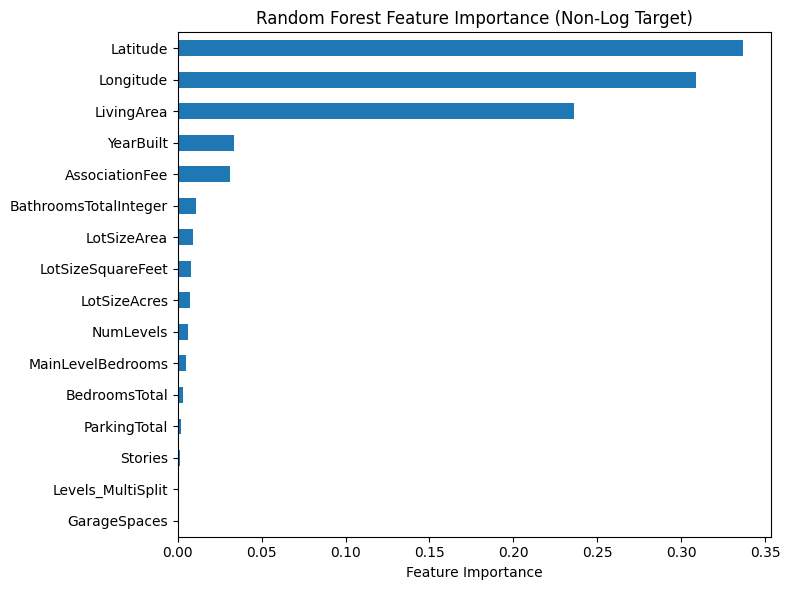

In [41]:
import matplotlib.pyplot as plt

# Feature importance for the non-log Random Forest (rf_model)
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(rf_importances)

plt.figure(figsize=(8, 6))
rf_importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (Non-Log Target)')
plt.tight_layout()
plt.show()

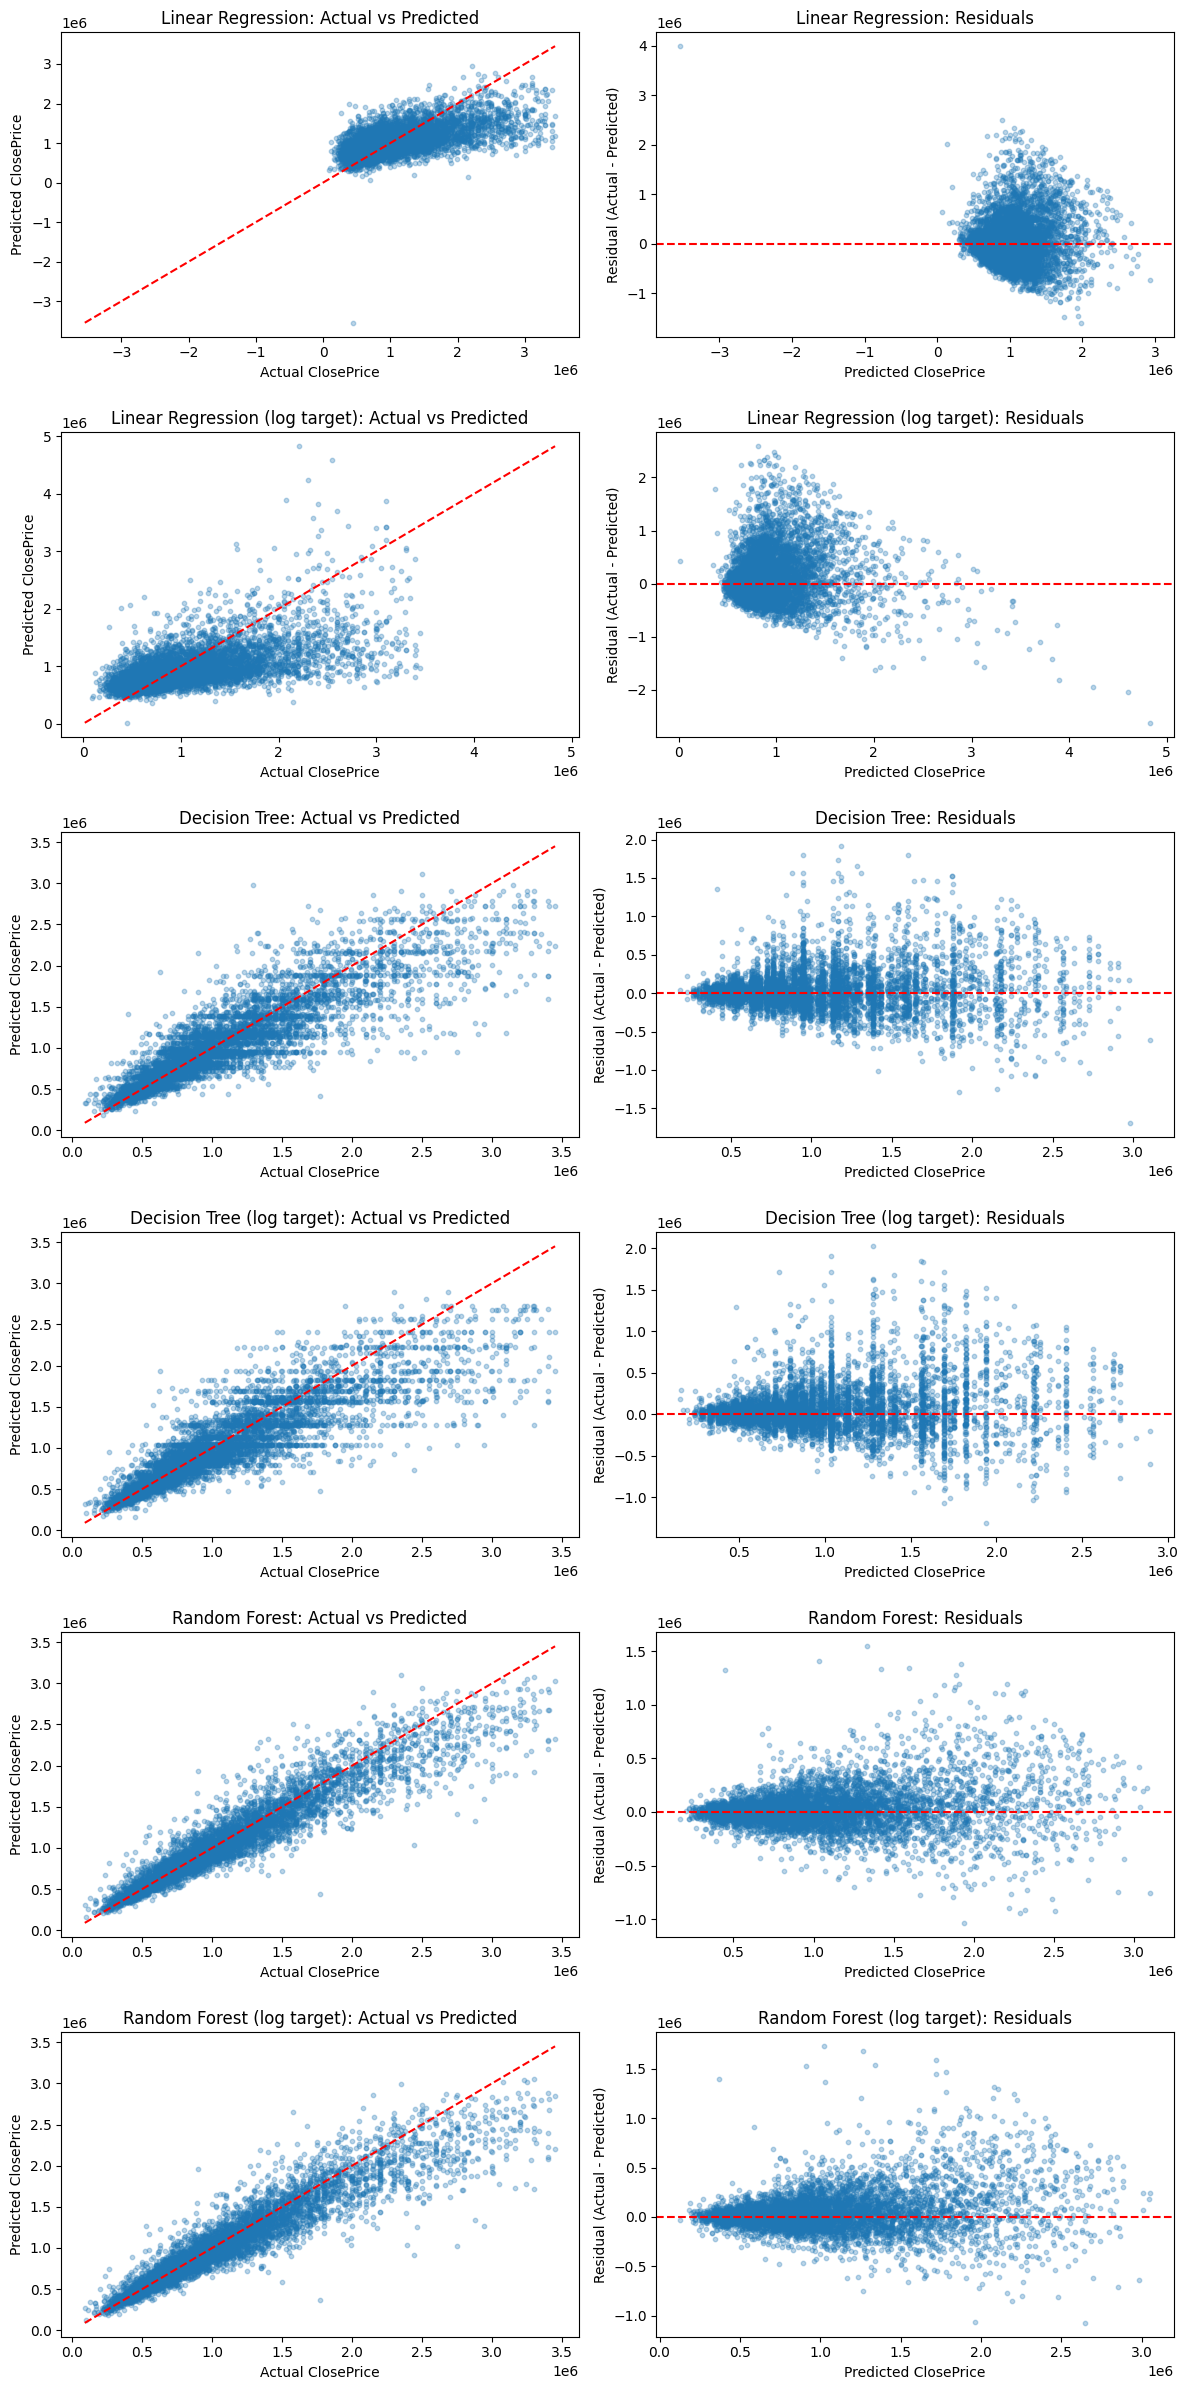

In [42]:
# Model diagnostics: actual vs. predicted and residuals for every model trained above
models_preds = {
    'Linear Regression': y_pred_full,
    'Linear Regression (log target)': y_pred_full_log,
    'Decision Tree': dt_preds,
    'Decision Tree (log target)': dt_log_preds,
    'Random Forest': rf_preds,
    'Random Forest (log target)': rf_log_preds,
}

fig, axes = plt.subplots(len(models_preds), 2, figsize=(12, 4 * len(models_preds)))

for i, (name, preds) in enumerate(models_preds.items()):
    preds = np.asarray(preds)
    residuals = y_test - preds

    axes[i, 0].scatter(y_test, preds, alpha=0.3, s=10)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    axes[i, 0].plot(lims, lims, 'r--')
    axes[i, 0].set_xlabel('Actual ClosePrice')
    axes[i, 0].set_ylabel('Predicted ClosePrice')
    axes[i, 0].set_title(f'{name}: Actual vs Predicted')

    axes[i, 1].scatter(preds, residuals, alpha=0.3, s=10)
    axes[i, 1].axhline(0, color='r', linestyle='--')
    axes[i, 1].set_xlabel('Predicted ClosePrice')
    axes[i, 1].set_ylabel('Residual (Actual - Predicted)')
    axes[i, 1].set_title(f'{name}: Residuals')

plt.tight_layout()
plt.show()